In [2]:
import pandas as pd
import seaborn as sns

In [3]:
import glob
import os
import pandas as pd

root = "/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes"

pattern = os.path.join(root, "set_*", "output", "qc", "qc_allelicity_summary.*.tsv")
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} qc_allelicity_summary files")
# print("\n".join(files[:5]))

dfs = []
for f in files:
    df = pd.read_csv(f, sep="\t")

    # set name is the suffix after qc_allelicity_summary.
    # e.g. qc_allelicity_summary.set_02_rep1.tsv -> set_02_rep1
    base = os.path.basename(f)
    set_name = base.replace("qc_allelicity_summary.", "").replace(".tsv", "")
    df["set"] = set_name

    # also store absolute path (useful for debugging)
    df["source_path"] = f

    dfs.append(df)

allelicity_all = pd.concat(dfs, ignore_index=True)

# optional: reorder cols nicely
cols = ["set", "vcf", "total_records", "biallelic_records", "multiallelic_records", "max_ALTs", "total_ALT_alleles", "source_path"]
allelicity_all = allelicity_all[cols]


Found 1 qc_allelicity_summary files


In [46]:
path = '/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep1/output/qc/qc_allelicity_summary.set_02_rep1.tsv'

In [49]:
path = '/carnegie/nobackup/scratch/tbellagio/pang/pang_experiment/pangenomes/set_02_rep1/output/qc/qc_sizes_biallelic.set_02_rep1.deconstruct.all_snarls.tsv'

In [50]:
snarls_top = pd.read_csv(path, sep = '\t')

In [51]:
snarls_top

,chrom,pos,id,class,size_signed,size_bp,is_conflict
0,TAIR10#0#Chr1,2,>1>8,INS,5919,5919,0
1,TAIR10#0#Chr1,892,>8>11,SNP,0,0,0
2,TAIR10#0#Chr1,1079,>11>13,DEL,-3,3,0
3,TAIR10#0#Chr1,6324,>18>20,INS,1,1,0
4,TAIR10#0#Chr1,8677,>22>24,INS,2,2,0
...,...,...,...,...,...,...,...
802488,TAIR10#0#Chr5,26975099,>2349299>2349302,SNP,0,0,0
802489,TAIR10#0#Chr5,26975288,>2349302>2349305,SNP,0,0,0
802490,TAIR10#0#Chr5,26975377,>2349305>2349308,SNP,0,0,0
802491,TAIR10#0#Chr5,26975423,>2349308>2349310,DEL,-7,7,0


<Axes: xlabel='class', ylabel='Count'>

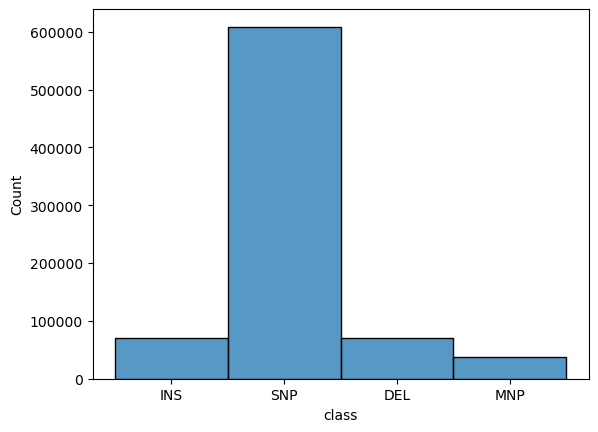

In [42]:
sns.histplot(snarls_top['class'])

In [26]:
snarls_top['class'].value_counts()

class
SNP    608539
INS     71192
DEL     69963
MNP     37051
Name: count, dtype: int64

class
SNP    608539
INS     71192
DEL     69963
MNP     37051
Name: count, dtype: int64

In [ ]:
snarls_all = pd.read_csv('qc_sizes_biallelic.set_02_rep1.deconstruct.all_snarls.tsv', sep = '\t')

In [6]:
snarls['vcf'].unique()

array(['set_02_rep1.deconstruct.top.vcf.gz',
       'set_02_rep1.deconstruct.all_snarls.vcf.gz'], dtype=object)

In [9]:
snarls_top = snarls[snarls['vcf'] == 'set_02_rep1.deconstruct.top.vcf.gz']

In [10]:
snarls_all = snarls[snarls['vcf'] == 'set_02_rep1.deconstruct.all_snarls.vcf.gz']

In [12]:
snarls_top['size_bp'].describe()

count    786745.000000
mean         15.681682
std         464.782422
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      126599.000000
Name: size_bp, dtype: float64

In [15]:
snarls_top

,vcf,chrom,pos,id,alt_index,class,size_bp,is_conflict
0,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,2,>1>8,1,INS,5919,0
1,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,892,>8>11,1,SNP,0,0
2,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,1079,>11>13,1,DEL,3,0
3,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,6324,>18>20,1,INS,1,0
4,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr1,8677,>22>24,1,INS,2,0
...,...,...,...,...,...,...,...,...
786740,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975099,>2349299>2349302,1,SNP,0,0
786741,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975288,>2349302>2349305,1,SNP,0,0
786742,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975377,>2349305>2349308,1,SNP,0,0
786743,set_02_rep1.deconstruct.top.vcf.gz,TAIR10#0#Chr5,26975423,>2349308>2349310,1,DEL,7,0
